# LLM Training Efficiency Analysis - Google Colab (EXTENDED)

**Project:** Training Efficiency Analysis Across Text Characteristics

This extended notebook merges the original replication experiments with the final confirming padding experiment where `max_length` is increased to 512.

---

## Setup Instructions

1. **Enable GPU**: Runtime → Change runtime type → GPU (T4)
2. **Run all cells in order**
3. **Estimated time**: 2-3 hours for full test

## Step 1: Check GPU

In [1]:
import torch

print("="*60)
print("GPU CHECK")
print("="*60)

if torch.cuda.is_available():
    print(f"✅ GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("❌ No GPU detected!")
    print("   Go to: Runtime → Change runtime type → GPU")
    raise RuntimeError("GPU is required for this project")

GPU CHECK
✅ GPU Available: Tesla T4
   Memory: 15.6 GB


## Step 2: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Google Drive mounted successfully!")

Mounted at /content/drive

✅ Google Drive mounted successfully!


## Step 3: Set Project Path

## Step 4: Install Dependencies (with version fixes)

In [3]:
print("Installing dependencies...\n")

# Install with specific compatible versions for Colab
!pip install -q --upgrade pip

# Install core ML libraries with compatible versions
!pip install -q -U "transformers>=4.40.0" \
                 "datasets>=2.14.0" \
                 "accelerate>=0.30.0" \
                 "evaluate>=0.4.0" \
                 "tokenizers>=0.15.0"

# Install data processing libraries
!pip install -q "pandas>=2.0.0" \
                 "numpy>=1.24.0" \
                 "scikit-learn>=1.3.0"

# Install visualization libraries
!pip install -q "matplotlib>=3.7.0" \
                 "seaborn>=0.12.0"

# Install utilities
!pip install -q "pyyaml>=6.0" \
                 "tqdm>=4.65.0"

# Install scipy for statistical tests
# Force-upgrade PEFT to fix clear_device_cache ImportError
!pip uninstall -y peft
!pip install -q peft>=0.11.0

!pip install -q "scipy>=1.10.0"

print("\n✅ All dependencies installed!")

Installing dependencies...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.6 MB/s eta 0:00:00
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1

✅ All dependencies installed!


## Step 5: Quick Pre-flight Test (Recommended)

Run this before the full experiment to verify that all three tokenizers load correctly and the IMDb dataset is accessible from Drive. This takes about 1–2 minutes and saves you from discovering an error 4 hours into the training run.

In [4]:
# Ensure project root is in path before importing src/
import sys, os
PROJECT_ROOT = '/content/drive/MyDrive/llm_efficiency_study'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# Quick pre-flight test: verifies all 3 tokenizers + dataset access
# Does NOT train anything. Expected time: ~1-2 minutes.

print("=" * 60)
print("PRE-FLIGHT SETUP TEST")
print("=" * 60)

from src.model_utils import load_tokenizer
from datasets import load_dataset

models_to_test = [
    "bert-base-uncased",
    "distilbert-base-uncased",
    "roberta-base"
]

print("\n1. Testing tokenizer loading for all 3 models...")
for model_name in models_to_test:
    tokenizer = load_tokenizer(model_name)
    test_text = "This is a quick sanity check."
    tokens = tokenizer(test_text)
    print(f"  ✅ {model_name}: loaded OK ({len(tokens['input_ids'])} tokens for test sentence)")

print("\n2. Testing IMDb and Emotion dataset access...")
imdb = load_dataset("imdb", split="train[:5]")  # Only 5 samples for speed
emotion = load_dataset("dair-ai/emotion", "split", split="train[:5]", trust_remote_code=True)
print(f"  ✅ IMDb: accessible (test sample length: {len(imdb[0]['text'].split())} words)")
print(f"  ✅ Emotion: accessible (test sample length: {len(emotion[0]['text'].split())} words)")

print("\n3. Testing config file...")
import yaml
with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)
print(f"  ✅ Config loaded: {len(cfg['models'])} models, {len(cfg['seeds'])} seeds, max_length={cfg["datasets"]["imdb"]["max_length"]}")

print("\n" + "=" * 60)
print("✅ ALL CHECKS PASSED - Ready to run the full experiment!")
print("=" * 60)


PRE-FLIGHT SETUP TEST

1. Testing tokenizer loading for all 3 models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  ✅ IMDb: accessible (test sample length: 288 words)
  ✅ Emotion: accessible (test sample length: 4 words)

3. Testing config file...
  ✅ Config loaded: 3 models, 3 seeds, max_length=512

✅ ALL CHECKS PASSED - Ready to run the full experiment!


---

### 📌 Why are we running this Extended Experiment?

In our previous Chapter 3 and Chapter 5 replication runs, we discovered something interesting:
- **Emotion Dataset** saw a massive **4x speedup** when using Dynamic Padding instead of Static Padding.
- **IMDb Dataset** saw **almost zero speedup** from Dynamic Padding.

**Our Hypothesis:** The benefit of dynamic padding depends on the *absolute text length* relative to the *max_length* limit.
- Emotion tweets are very short (avg 25 tokens). With a `max_length` of 128, static padding forces 100+ empty padding tokens per tweet. Dynamic padding removes this massive waste.
- IMDb reviews are long (avg 279 tokens). With our original `max_length` of 256, we were actively *truncating* most reviews. Therefore, the batch matrix was completely full of actual text, leaving no empty space for dynamic padding to optimize!

**The Test:** If we increase the IMDb `max_length` to **512**, the full reviews will fit, leaving empty padding space in the matrix for shorter reviews. Dynamic padding *should* finally show an improvement.

### 🔍 Understanding the Data Profiles

Let's look at a concrete example of the two datasets beneath to see the difference in length.
- Notice how the IMDb review is hundreds of characters long and varies wildly from review to review.
- Notice how the Emotion tweet is extremely short and uniform.

This physical difference in token footprint is what dictates whether dynamic padding saves GPU computation time.

In [5]:
from datasets import load_dataset

print("Downloading datasets to show examples...")
imdb = load_dataset('imdb', split='train')
emotion = load_dataset('dair-ai/emotion', 'split', split='train', trust_remote_code=True)

print("\n" + "="*60)
print("1. IMDB REVIEW EXAMPLE (Variable length, Long text)")
print("="*60)
print(f"Text (first 600 chars): {imdb[0]['text'][:600]}...")
print(f"\nLength in characters: {len(imdb[0]['text'])}")

print("\n" + "="*60)
print("2. EMOTION TWEET EXAMPLE (Uniform length, Short text)")
print("="*60)
print(f"Text: {emotion[0]['text']}")
print(f"\nLength in characters: {len(emotion[0]['text'])}")
print("="*60)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



1. IMDB REVIEW EXAMPLE (Variable length, Long text)
Text (first 600 chars): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political is...

Length in characters: 1640

2. EMOTION TWEET EXAMPLE (Uniform length, Short text)
Text: i didnt feel humiliated

Length in characters: 23


In this extended test, we run the IMDb dynamic padding test again but with **`max_length = 512`** and **3 epochs** on both **BERT**, **DistilBERT**, and **RoBERTa** architectures. Now the entire text fits, and we should finally see some wasted empty padding space that dynamic padding can optimize.

*Note: To prevent Colab session timeouts and make it easier to track progress, the executions below have been split into separate cells for each model.*

In [6]:
# Force reload src/ modules (picks up any Drive file updates)
import sys, importlib
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

# BERT-base on IMDB — inline (no subprocess)
# Expected time: ~1.5-2 hours

# Hotfix: patch missing clear_device_cache before peft loads
try:
    from accelerate.utils.memory import clear_device_cache
except ImportError:
    import torch, accelerate.utils.memory as _mem
    _mem.clear_device_cache = lambda *a, **k: torch.cuda.empty_cache() if torch.cuda.is_available() else None

import yaml, os, sys
sys.path.insert(0, os.getcwd())

from src.experiment_runner import run_padding_comparison
# Monkey-patch: guarantee label->labels rename regardless of Drive file version
import src.data_processing as _dp
_orig_imdb = _dp.load_and_preprocess_imdb
_orig_emotion = _dp.load_and_preprocess_emotion
def _patched_imdb(*a, **kw):
    ds = _orig_imdb(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
def _patched_emotion(*a, **kw):
    ds = _orig_emotion(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
_dp.load_and_preprocess_imdb = _patched_imdb
_dp.load_and_preprocess_emotion = _patched_emotion


with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["models"] = [m for m in cfg["models"] if m["name"] == "bert-base-uncased"]

print("="*60)
print("IMDB: BERT-base")
print("="*60)
print("Model: bert-base-uncased | max_length:", cfg["datasets"]["imdb"]["max_length"])
print("Seeds:", cfg["seeds"], "| Strategies:", cfg["padding_strategies"])
print("Batch size:", cfg["training"]["batch_size"], "| Accumulation steps:", cfg["training"].get("gradient_accumulation_steps", 1))
print("\nStarting training...\n")

df = run_padding_comparison(cfg, output_dir="results", dataset_name="imdb")

print("\n============================================================")
print("DONE: BERT-base on IMDB")
if df is not None and len(df) > 0:
    print(df[["model_name","padding_strategy","seed","accuracy","total_time_minutes"]].to_string())


IMDB: BERT-base
Model: bert-base-uncased | max_length: 512
Seeds: [42, 123, 456] | Strategies: ['static', 'dynamic']
Batch size: 8 | Accumulation steps: 2

Starting training...



Evaluating Padding Strategies on imdb for bert-base-uncased:   0%|          | 0/2 [00:00<?, ?it/s]

Running bert-base-uncased on imdb (static):   0%|          | 0/3 [00:00<?, ?it/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Evaluating Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

Measuring Latency:   0%|          | 0/13 [00:00<?, ?it/s]


DONE: BERT-base on IMDB
          model_name padding_strategy  seed  accuracy  total_time_minutes
0  bert-base-uncased           static    42   0.93960           32.771775
1  bert-base-uncased           static   123   0.94040           32.902865
2  bert-base-uncased           static   456   0.93912           32.780585
3  bert-base-uncased          dynamic    42   0.93896           31.507457
4  bert-base-uncased          dynamic   123   0.93796           31.605485
5  bert-base-uncased          dynamic   456   0.93920           31.603298


In [7]:
# Force reload src/ modules (picks up any Drive file updates)
import sys, importlib
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

# DistilBERT-base on IMDB — inline (no subprocess)
# Expected time: ~1-1.5 hours

# Hotfix: patch missing clear_device_cache before peft loads
try:
    from accelerate.utils.memory import clear_device_cache
except ImportError:
    import torch, accelerate.utils.memory as _mem
    _mem.clear_device_cache = lambda *a, **k: torch.cuda.empty_cache() if torch.cuda.is_available() else None

import yaml, os, sys
sys.path.insert(0, os.getcwd())

from src.experiment_runner import run_padding_comparison
# Monkey-patch: guarantee label->labels rename regardless of Drive file version
import src.data_processing as _dp
_orig_imdb = _dp.load_and_preprocess_imdb
_orig_emotion = _dp.load_and_preprocess_emotion
def _patched_imdb(*a, **kw):
    ds = _orig_imdb(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
def _patched_emotion(*a, **kw):
    ds = _orig_emotion(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
_dp.load_and_preprocess_imdb = _patched_imdb
_dp.load_and_preprocess_emotion = _patched_emotion


with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["models"] = [m for m in cfg["models"] if m["name"] == "distilbert-base-uncased"]

print("="*60)
print("IMDB: DistilBERT-base")
print("="*60)
print("Model: distilbert-base-uncased | max_length:", cfg["datasets"]["imdb"]["max_length"])
print("Seeds:", cfg["seeds"], "| Strategies:", cfg["padding_strategies"])
print("Batch size:", cfg["training"]["batch_size"], "| Accumulation steps:", cfg["training"].get("gradient_accumulation_steps", 1))
print("\nStarting training...\n")

df = run_padding_comparison(cfg, output_dir="results", dataset_name="imdb")

print("\n============================================================")
print("DONE: DistilBERT-base on IMDB")
if df is not None and len(df) > 0:
    print(df[["model_name","padding_strategy","seed","accuracy","total_time_minutes"]].to_string())


IMDB: DistilBERT-base
Model: distilbert-base-uncased | max_length: 512
Seeds: [42, 123, 456] | Strategies: ['static', 'dynamic']
Batch size: 8 | Accumulation steps: 2

Starting training...



Evaluating Padding Strategies on imdb for distilbert-base-uncased:   0%|          | 0/2 [00:00<?, ?it/s]

Running distilbert-base-uncased on imdb (static):   0%|          | 0/3 [00:00<?, ?it/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluating Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

Measuring Latency:   0%|          | 0/13 [00:00<?, ?it/s]


DONE: DistilBERT-base on IMDB
                 model_name padding_strategy  seed  accuracy  total_time_minutes
0         bert-base-uncased           static    42   0.93960           32.771775
1         bert-base-uncased           static   123   0.94040           32.902865
2         bert-base-uncased           static   456   0.93912           32.780585
3         bert-base-uncased          dynamic    42   0.93896           31.507457
4         bert-base-uncased          dynamic   123   0.93796           31.605485
5         bert-base-uncased          dynamic   456   0.93920           31.603298
6   distilbert-base-uncased           static    42   0.93092           16.888458
7   distilbert-base-uncased           static   123   0.92892           16.715368
8   distilbert-base-uncased           static   456   0.93228           16.805433
9   distilbert-base-uncased          dynamic    42   0.93128           16.202468
10  distilbert-base-uncased          dynamic   123   0.92896           16.3872

In [8]:
# Force reload src/ modules (picks up any Drive file updates)
import sys, importlib
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

# RoBERTa-base on IMDB — inline (no subprocess)
# Expected time: ~1.5-2 hours

# Hotfix: patch missing clear_device_cache before peft loads
try:
    from accelerate.utils.memory import clear_device_cache
except ImportError:
    import torch, accelerate.utils.memory as _mem
    _mem.clear_device_cache = lambda *a, **k: torch.cuda.empty_cache() if torch.cuda.is_available() else None

import yaml, os, sys
sys.path.insert(0, os.getcwd())

from src.experiment_runner import run_padding_comparison
# Monkey-patch: guarantee label->labels rename regardless of Drive file version
import src.data_processing as _dp
_orig_imdb = _dp.load_and_preprocess_imdb
_orig_emotion = _dp.load_and_preprocess_emotion
def _patched_imdb(*a, **kw):
    ds = _orig_imdb(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
def _patched_emotion(*a, **kw):
    ds = _orig_emotion(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
_dp.load_and_preprocess_imdb = _patched_imdb
_dp.load_and_preprocess_emotion = _patched_emotion


with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["models"] = [m for m in cfg["models"] if m["name"] == "roberta-base"]

print("="*60)
print("IMDB: RoBERTa-base")
print("="*60)
print("Model: roberta-base | max_length:", cfg["datasets"]["imdb"]["max_length"])
print("Seeds:", cfg["seeds"], "| Strategies:", cfg["padding_strategies"])
print("Batch size:", cfg["training"]["batch_size"], "| Accumulation steps:", cfg["training"].get("gradient_accumulation_steps", 1))
print("\nStarting training...\n")

df = run_padding_comparison(cfg, output_dir="results", dataset_name="imdb")

print("\n============================================================")
print("DONE: RoBERTa-base on IMDB")
if df is not None and len(df) > 0:
    print(df[["model_name","padding_strategy","seed","accuracy","total_time_minutes"]].to_string())


IMDB: RoBERTa-base
Model: roberta-base | max_length: 512
Seeds: [42, 123, 456] | Strategies: ['static', 'dynamic']
Batch size: 8 | Accumulation steps: 2

Starting training...



Evaluating Padding Strategies on imdb for roberta-base:   0%|          | 0/2 [00:00<?, ?it/s]

Running roberta-base on imdb (static):   0%|          | 0/3 [00:00<?, ?it/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Evaluating Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

Measuring Latency:   0%|          | 0/13 [00:00<?, ?it/s]


DONE: RoBERTa-base on IMDB
                 model_name padding_strategy  seed  accuracy  total_time_minutes
0         bert-base-uncased           static    42   0.93960           32.771775
1         bert-base-uncased           static   123   0.94040           32.902865
2         bert-base-uncased           static   456   0.93912           32.780585
3         bert-base-uncased          dynamic    42   0.93896           31.507457
4         bert-base-uncased          dynamic   123   0.93796           31.605485
5         bert-base-uncased          dynamic   456   0.93920           31.603298
6   distilbert-base-uncased           static    42   0.93092           16.888458
7   distilbert-base-uncased           static   123   0.92892           16.715368
8   distilbert-base-uncased           static   456   0.93228           16.805433
9   distilbert-base-uncased          dynamic    42   0.93128           16.202468
10  distilbert-base-uncased          dynamic   123   0.92896           16.387273


In [9]:
# Force reload src/ modules (picks up any Drive file updates)
import sys, importlib
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

# BERT-base on EMOTION — inline (no subprocess)
# Expected time: ~30-45 min

# Hotfix: patch missing clear_device_cache before peft loads
try:
    from accelerate.utils.memory import clear_device_cache
except ImportError:
    import torch, accelerate.utils.memory as _mem
    _mem.clear_device_cache = lambda *a, **k: torch.cuda.empty_cache() if torch.cuda.is_available() else None

import yaml, os, sys
sys.path.insert(0, os.getcwd())

from src.experiment_runner import run_padding_comparison
# Monkey-patch: guarantee label->labels rename regardless of Drive file version
import src.data_processing as _dp
_orig_imdb = _dp.load_and_preprocess_imdb
_orig_emotion = _dp.load_and_preprocess_emotion
def _patched_imdb(*a, **kw):
    ds = _orig_imdb(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
def _patched_emotion(*a, **kw):
    ds = _orig_emotion(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
_dp.load_and_preprocess_imdb = _patched_imdb
_dp.load_and_preprocess_emotion = _patched_emotion


with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["models"] = [m for m in cfg["models"] if m["name"] == "bert-base-uncased"]

print("="*60)
print("EMOTION: BERT-base")
print("="*60)
print("Model: bert-base-uncased | max_length:", cfg["datasets"]["emotion"]["max_length"])
print("Seeds:", cfg["seeds"], "| Strategies:", cfg["padding_strategies"])
print("Batch size:", cfg["training"]["batch_size"], "| Accumulation steps:", cfg["training"].get("gradient_accumulation_steps", 1))
print("\nStarting training...\n")

df = run_padding_comparison(cfg, output_dir="results", dataset_name="emotion")

print("\n============================================================")
print("DONE: BERT-base on EMOTION")
if df is not None and len(df) > 0:
    print(df[["model_name","padding_strategy","seed","accuracy","total_time_minutes"]].to_string())


EMOTION: BERT-base
Model: bert-base-uncased | max_length: 128
Seeds: [42, 123, 456] | Strategies: ['static', 'dynamic']
Batch size: 8 | Accumulation steps: 2

Starting training...



Evaluating Padding Strategies on emotion for bert-base-uncased:   0%|          | 0/2 [00:00<?, ?it/s]

Running bert-base-uncased on emotion (static):   0%|          | 0/3 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Evaluating Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Measuring Latency:   0%|          | 0/13 [00:00<?, ?it/s]


DONE: BERT-base on EMOTION
          model_name padding_strategy  seed  accuracy  total_time_minutes
0  bert-base-uncased           static    42    0.9310            8.529553
1  bert-base-uncased           static   123    0.9255            8.504360
2  bert-base-uncased           static   456    0.9245            8.562793
3  bert-base-uncased          dynamic    42    0.9300            7.711563
4  bert-base-uncased          dynamic   123    0.9250            7.623372
5  bert-base-uncased          dynamic   456    0.9300            7.555918


In [10]:
# Force reload src/ modules (picks up any Drive file updates)
import sys, importlib
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

# DistilBERT-base on EMOTION — inline (no subprocess)
# Expected time: ~20-30 min

# Hotfix: patch missing clear_device_cache before peft loads
try:
    from accelerate.utils.memory import clear_device_cache
except ImportError:
    import torch, accelerate.utils.memory as _mem
    _mem.clear_device_cache = lambda *a, **k: torch.cuda.empty_cache() if torch.cuda.is_available() else None

import yaml, os, sys
sys.path.insert(0, os.getcwd())

from src.experiment_runner import run_padding_comparison
# Monkey-patch: guarantee label->labels rename regardless of Drive file version
import src.data_processing as _dp
_orig_imdb = _dp.load_and_preprocess_imdb
_orig_emotion = _dp.load_and_preprocess_emotion
def _patched_imdb(*a, **kw):
    ds = _orig_imdb(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
def _patched_emotion(*a, **kw):
    ds = _orig_emotion(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
_dp.load_and_preprocess_imdb = _patched_imdb
_dp.load_and_preprocess_emotion = _patched_emotion


with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["models"] = [m for m in cfg["models"] if m["name"] == "distilbert-base-uncased"]

print("="*60)
print("EMOTION: DistilBERT-base")
print("="*60)
print("Model: distilbert-base-uncased | max_length:", cfg["datasets"]["emotion"]["max_length"])
print("Seeds:", cfg["seeds"], "| Strategies:", cfg["padding_strategies"])
print("Batch size:", cfg["training"]["batch_size"], "| Accumulation steps:", cfg["training"].get("gradient_accumulation_steps", 1))
print("\nStarting training...\n")

df = run_padding_comparison(cfg, output_dir="results", dataset_name="emotion")

print("\n============================================================")
print("DONE: DistilBERT-base on EMOTION")
if df is not None and len(df) > 0:
    print(df[["model_name","padding_strategy","seed","accuracy","total_time_minutes"]].to_string())


EMOTION: DistilBERT-base
Model: distilbert-base-uncased | max_length: 128
Seeds: [42, 123, 456] | Strategies: ['static', 'dynamic']
Batch size: 8 | Accumulation steps: 2

Starting training...



Evaluating Padding Strategies on emotion for distilbert-base-uncased:   0%|          | 0/2 [00:00<?, ?it/s]

Running distilbert-base-uncased on emotion (static):   0%|          | 0/3 [00:00<?, ?it/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluating Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Measuring Latency:   0%|          | 0/13 [00:00<?, ?it/s]


DONE: DistilBERT-base on EMOTION
                 model_name padding_strategy  seed  accuracy  total_time_minutes
0         bert-base-uncased           static    42    0.9310            8.529553
1         bert-base-uncased           static   123    0.9255            8.504360
2         bert-base-uncased           static   456    0.9245            8.562793
3         bert-base-uncased          dynamic    42    0.9300            7.711563
4         bert-base-uncased          dynamic   123    0.9250            7.623372
5         bert-base-uncased          dynamic   456    0.9300            7.555918
6   distilbert-base-uncased           static    42    0.9280            4.780037
7   distilbert-base-uncased           static   123    0.9240            4.758060
8   distilbert-base-uncased           static   456    0.9265            4.896558
9   distilbert-base-uncased          dynamic    42    0.9260            4.355403
10  distilbert-base-uncased          dynamic   123    0.9275            4.2

In [11]:
# Force reload src/ modules (picks up any Drive file updates)
import sys, importlib
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

# RoBERTa-base on EMOTION — inline (no subprocess)
# Expected time: ~30-45 min

# Hotfix: patch missing clear_device_cache before peft loads
try:
    from accelerate.utils.memory import clear_device_cache
except ImportError:
    import torch, accelerate.utils.memory as _mem
    _mem.clear_device_cache = lambda *a, **k: torch.cuda.empty_cache() if torch.cuda.is_available() else None

import yaml, os, sys
sys.path.insert(0, os.getcwd())

from src.experiment_runner import run_padding_comparison
# Monkey-patch: guarantee label->labels rename regardless of Drive file version
import src.data_processing as _dp
_orig_imdb = _dp.load_and_preprocess_imdb
_orig_emotion = _dp.load_and_preprocess_emotion
def _patched_imdb(*a, **kw):
    ds = _orig_imdb(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
def _patched_emotion(*a, **kw):
    ds = _orig_emotion(*a, **kw)
    for sp in ds:
        if "label" in ds[sp].column_names and "labels" not in ds[sp].column_names:
            ds[sp] = ds[sp].rename_column("label", "labels")
    return ds
_dp.load_and_preprocess_imdb = _patched_imdb
_dp.load_and_preprocess_emotion = _patched_emotion


with open("configs/extended_imdb_config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["models"] = [m for m in cfg["models"] if m["name"] == "roberta-base"]

print("="*60)
print("EMOTION: RoBERTa-base")
print("="*60)
print("Model: roberta-base | max_length:", cfg["datasets"]["emotion"]["max_length"])
print("Seeds:", cfg["seeds"], "| Strategies:", cfg["padding_strategies"])
print("Batch size:", cfg["training"]["batch_size"], "| Accumulation steps:", cfg["training"].get("gradient_accumulation_steps", 1))
print("\nStarting training...\n")

df = run_padding_comparison(cfg, output_dir="results", dataset_name="emotion")

print("\n============================================================")
print("DONE: RoBERTa-base on EMOTION")
if df is not None and len(df) > 0:
    print(df[["model_name","padding_strategy","seed","accuracy","total_time_minutes"]].to_string())


EMOTION: RoBERTa-base
Model: roberta-base | max_length: 128
Seeds: [42, 123, 456] | Strategies: ['static', 'dynamic']
Batch size: 8 | Accumulation steps: 2

Starting training...



Evaluating Padding Strategies on emotion for roberta-base:   0%|          | 0/2 [00:00<?, ?it/s]

Running roberta-base on emotion (static):   0%|          | 0/3 [00:00<?, ?it/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Evaluating Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Measuring Latency:   0%|          | 0/13 [00:00<?, ?it/s]


DONE: RoBERTa-base on EMOTION
                 model_name padding_strategy  seed  accuracy  total_time_minutes
0         bert-base-uncased           static    42    0.9310            8.529553
1         bert-base-uncased           static   123    0.9255            8.504360
2         bert-base-uncased           static   456    0.9245            8.562793
3         bert-base-uncased          dynamic    42    0.9300            7.711563
4         bert-base-uncased          dynamic   123    0.9250            7.623372
5         bert-base-uncased          dynamic   456    0.9300            7.555918
6   distilbert-base-uncased           static    42    0.9280            4.780037
7   distilbert-base-uncased           static   123    0.9240            4.758060
8   distilbert-base-uncased           static   456    0.9265            4.896558
9   distilbert-base-uncased          dynamic    42    0.9260            4.355403
10  distilbert-base-uncased          dynamic   123    0.9275            4.2721

### 1b. Validation Experiment (Emotion Dataset)

To prove that dynamic padding only fails on IMDb because of the text length, we will now run the exact same padding test on the **Emotion** dataset. Because tweets are very short (~25 tokens), dynamic padding should have plenty of empty space to optimize and will likely produce a massive speedup.

---
## RESULTS ANALYSIS & VISUALIZATION
---

### 📊 Understanding the Efficiency Metrics

When the experiment finishes, it will print a large table. Here is exactly what those metrics prove:

**Performance Metrics:**
- **Accuracy / F1 / Precision / Recall**: These show that the model learns just as well regardless of the padding strategy. (We are optimizing speed without sacrificing quality).

**Efficiency Metrics (The Core Focus):**
- **Total Time (Minutes)**: The most important metric. Does dynamic padding reduce the overall clock time the GPU spends training the 3 epochs?
- **Avg Epoch Time**: Breaks down the time saved per pass over the data.
- **Inference Time (ms)**: How fast the model can classify a new un-seen review. Dynamic padding often speeds this up too!
- **GPU Peak Memory (MB)**: Because dynamic padding removes tokens, smaller matrices consume less VRAM, preventing Out Of Memory (OOM) crashes.

In [12]:
import pandas as pd
import os

results_dir = 'results/tables'
imdb_file = f'{results_dir}/padding_comparison_imdb.csv'
emotion_file = f'{results_dir}/padding_comparison_emotion.csv'

print('\n' + '='*60)
print('EXTENDED PADDING COMPARISON RESULTS')
print('='*60)

if os.path.exists(imdb_file):
    print('\n--- IMDB RESULTS ---')
    df_imdb = pd.read_csv(imdb_file)
    print(df_imdb[['model_name', 'padding_strategy', 'seed', 'accuracy', 'precision', 'recall', 'f1', \
              'total_time_minutes', 'avg_epoch_time_minutes', \
              'inference_time_per_sample_ms', 'gpu_peak_memory_mb']])
else:
    print('\nNo IMDB results found.')
    df_imdb = None

if os.path.exists(emotion_file):
    print('\n--- EMOTION RESULTS ---')
    df_emotion = pd.read_csv(emotion_file)
    print(df_emotion[['model_name', 'padding_strategy', 'seed', 'accuracy', 'precision', 'recall', 'f1', \
              'total_time_minutes', 'avg_epoch_time_minutes', \
              'inference_time_per_sample_ms', 'gpu_peak_memory_mb']])
else:
    print('\nNo Emotion results found.')
    df_emotion = None
    df = df_imdb  # For visualization downstream



EXTENDED PADDING COMPARISON RESULTS

--- IMDB RESULTS ---
                 model_name padding_strategy  seed  accuracy  precision  \
0         bert-base-uncased           static    42   0.93960   0.935351   
1         bert-base-uncased           static   123   0.94040   0.931697   
2         bert-base-uncased           static   456   0.93912   0.932818   
3         bert-base-uncased          dynamic    42   0.93896   0.933824   
4         bert-base-uncased          dynamic   123   0.93796   0.932323   
5         bert-base-uncased          dynamic   456   0.93920   0.938148   
6   distilbert-base-uncased           static    42   0.93092   0.921314   
7   distilbert-base-uncased           static   123   0.92892   0.932903   
8   distilbert-base-uncased           static   456   0.93228   0.927323   
9   distilbert-base-uncased          dynamic    42   0.93128   0.921633   
10  distilbert-base-uncased          dynamic   123   0.92896   0.922737   
11  distilbert-base-uncased          dyna


GENERATING VISUALIZATIONS

1. Training Time Comparison (Lower is Better)
Visualization failed: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (3).


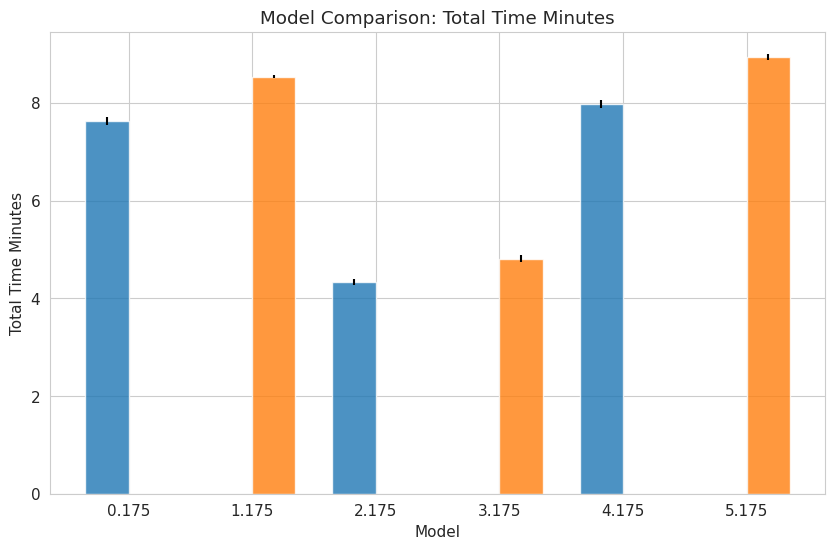

In [13]:
# Generate and display result visualizations inline
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    print('\n' + '='*60)
    print('GENERATING VISUALIZATIONS')
    print('='*60)

    try:
        from src.visualization import plot_model_comparison, plot_tradeoff_analysis

        print('\n1. Training Time Comparison (Lower is Better)')
        plot_model_comparison(df, metric='total_time_minutes', show=True)

        print('\n2. GPU Memory Usage (Lower is Better)')
        plot_model_comparison(df, metric='gpu_peak_memory_mb', show=True)

        print('\n3. Accuracy vs Time Trade-off')
        plot_tradeoff_analysis(df, x_metric='total_time_minutes', y_metric='accuracy', show=True)

    except Exception as e:
        print(f'Visualization failed: {e}')


## Save & Download Results

In [14]:
import shutil
from datetime import datetime
from google.colab import files

if df is not None:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_name = f'extended_results_backup_{timestamp}'
    print(f'\nCreating backup: {backup_name}.zip')

    shutil.make_archive(backup_name, 'zip', '.', 'results')
    files.download(f'{backup_name}.zip')
    print('✅ Download started!')



Creating backup: extended_results_backup_20260301_030836.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
